AirFly Insights – Milestone 4
Advanced Analytics, Correlation & Predictive Insights

In [33]:
#AirFly Insights – Milestone 4
#Advanced Analytics, Correlation & Predictive Insights

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [34]:
#Load Dataset

df = pd.read_csv('data/Flight_Dataset.csv')
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [ ]:
#Feature Engineering (if not already done)

df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], errors='coerce')

df['YEAR'] = df['FL_DATE'].dt.year
df['MONTH'] = df['FL_DATE'].dt.month
df['WEEKDAY'] = df['FL_DATE'].dt.day_name()
df['DEP_HOUR'] = (df['CRS_DEP_TIME'] // 100)

In [36]:
#Filter Active Flights

active = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)]

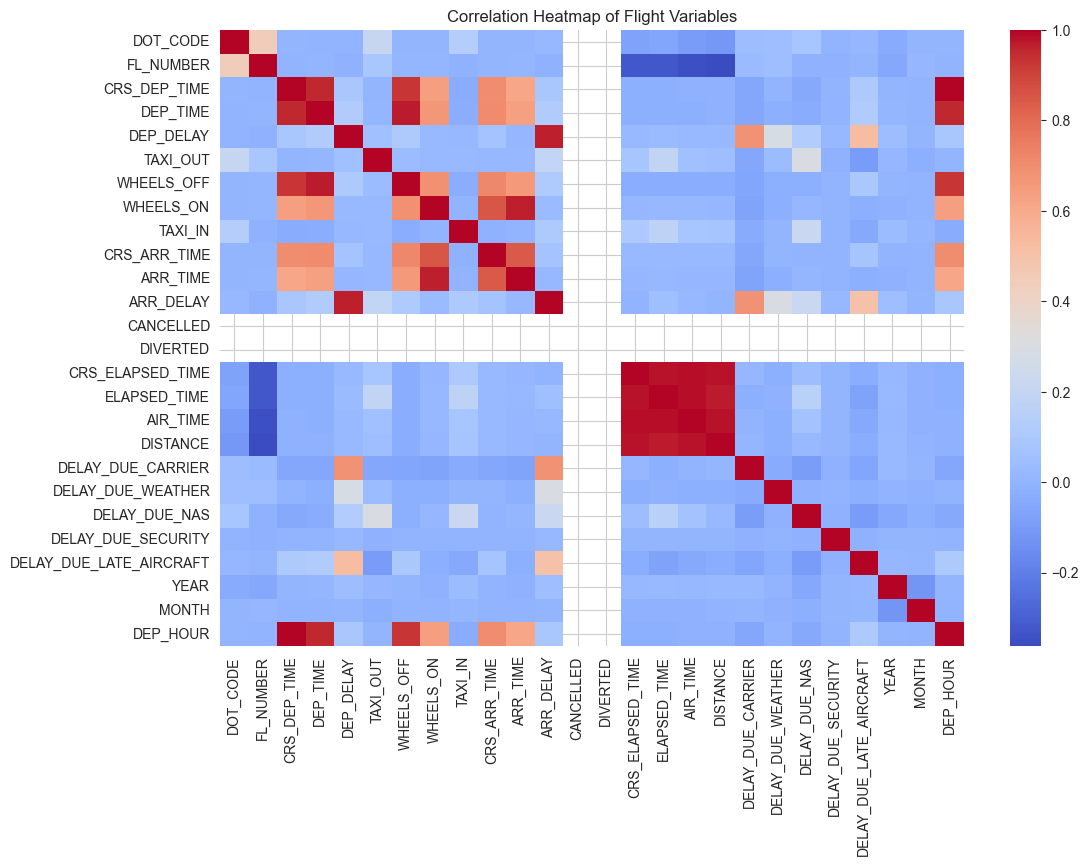

In [37]:
#PART 1: CORRELATION ANALYSIS (CORE ANALYTICS)

#Correlation Heatmap
numeric_cols = active.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_cols.corr(), cmap="coolwarm", annot=False)

plt.title("Correlation Heatmap of Flight Variables")
plt.show()       #Delay-related variables show strong correlations, Distance vs delay may show weak/moderate relation

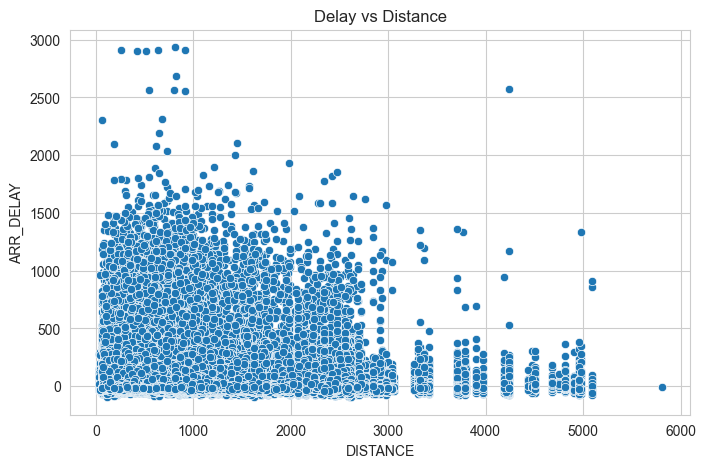

In [38]:
#PART 2: DELAY PATTERN ANALYSIS

#Delay vs Distance
plt.figure(figsize=(8,5))
sns.scatterplot(x='DISTANCE', y='ARR_DELAY', data=active)

plt.title("Delay vs Distance")
plt.show()    #Longer routes do not always mean higher delays, Operational factors dominate

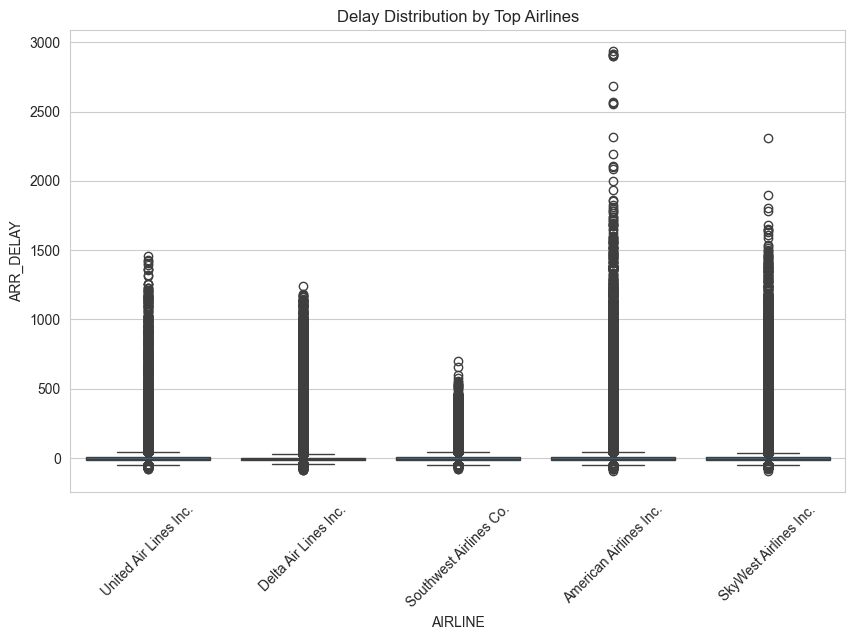

In [39]:
#Delay Distribution by Airline

top_airlines = active['AIRLINE'].value_counts().head(5).index
filtered = active[active['AIRLINE'].isin(top_airlines)]

plt.figure(figsize=(10,6))
sns.boxplot(x='AIRLINE', y='ARR_DELAY', data=filtered)

plt.title("Delay Distribution by Top Airlines")
plt.xticks(rotation=45)
plt.show()       #Some airlines have consistent delays, Others show high variability

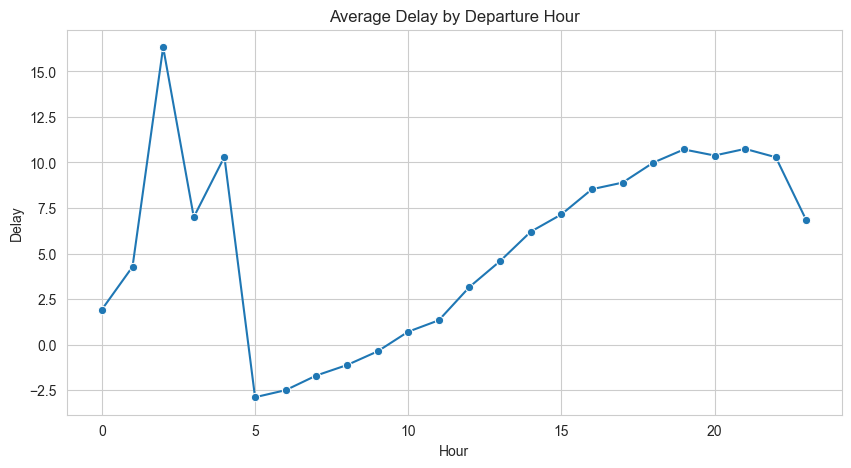

In [40]:
#PART 3: TIME-BASED ANALYTICS

#Hourly Delay Pattern
hour_delay = active.groupby('DEP_HOUR')['ARR_DELAY'].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=hour_delay.index, y=hour_delay.values, marker='o')

plt.title("Average Delay by Departure Hour")
plt.xlabel("Hour")
plt.ylabel("Delay")
plt.show()                  #Evening flights tend to have higher delays , Mid-day flights are more stable


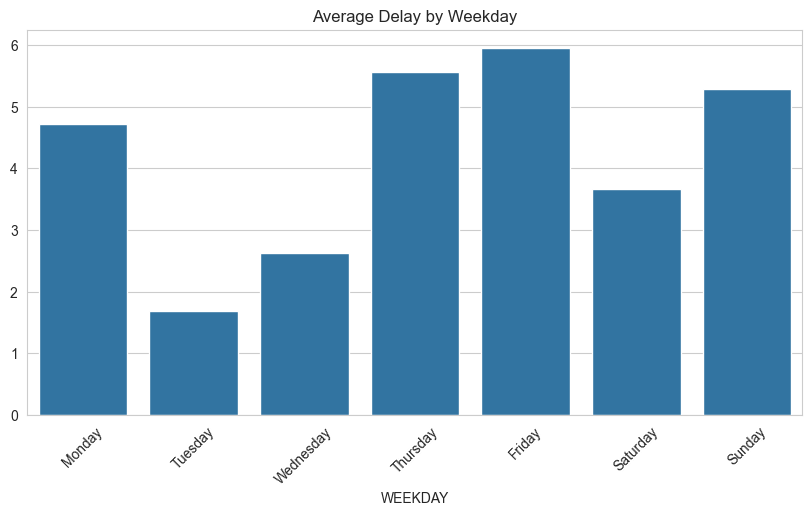

In [41]:
#Weekly Delay Pattern

weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

weekday_delay = active.groupby('WEEKDAY')['ARR_DELAY'].mean().reindex(weekday_order)

plt.figure(figsize=(10,5))
sns.barplot(x=weekday_delay.index, y=weekday_delay.values)

plt.xticks(rotation=45)
plt.title("Average Delay by Weekday")
plt.show()                                       #Weekends may show different congestion patterns


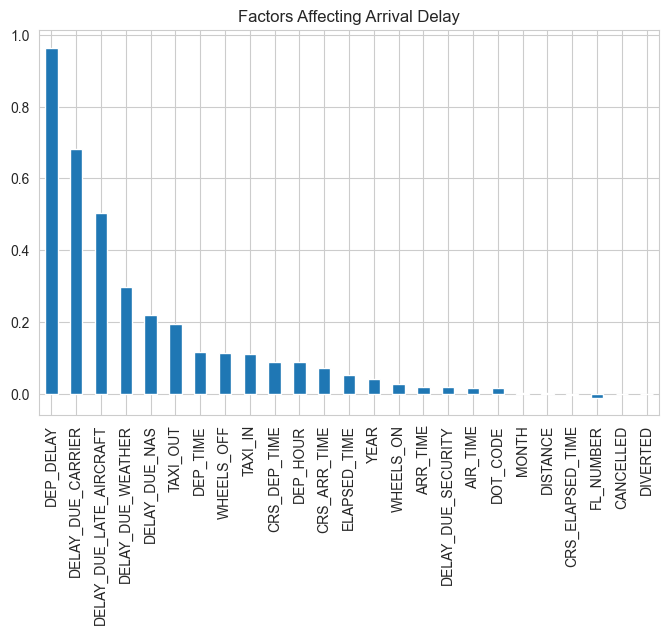

In [42]:
#PART 4: FEATURE IMPORTANCE

#Which factors affect delay most?
corr = numeric_cols.corr()['ARR_DELAY'].sort_values(ascending=False)

plt.figure(figsize=(8,5))
corr.drop('ARR_DELAY').plot(kind='bar')

plt.title("Factors Affecting Arrival Delay")
plt.show()                                      #Carrier delay & late aircraft delay strongly influence arrival delay

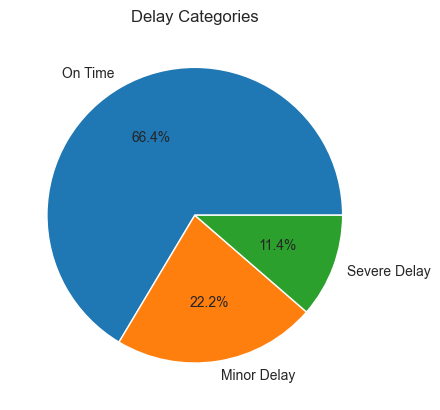

In [43]:
#PART 5: PREDICTIVE THINKING

#Simple Delay Risk Categorization
def delay_category(x):
    if x <= 0:
        return "On Time"
    elif x <= 30:
        return "Minor Delay"
    else:
        return "Severe Delay"

active['DELAY_CATEGORY'] = active['ARR_DELAY'].apply(delay_category)

active['DELAY_CATEGORY'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Delay Categories")
plt.ylabel("")
plt.show()                                    #Most delays are minor , Severe delays are relatively fewer

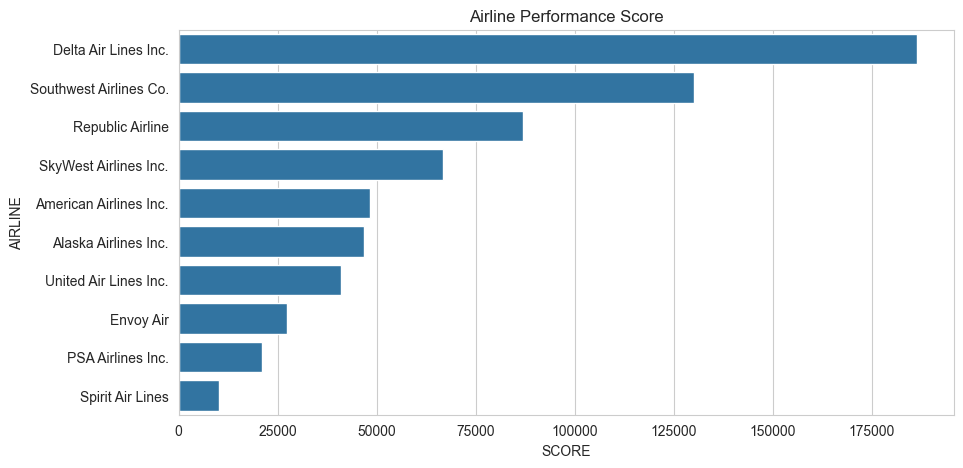

In [44]:

#PART 6: AIRLINE PERFORMANCE SCORE

# Composite Score
performance = active.groupby('AIRLINE').agg({
    'ARR_DELAY':'mean',
    'DEP_DELAY':'mean',
    'FL_NUMBER':'count'
})

performance['SCORE'] = performance['FL_NUMBER'] / (performance['ARR_DELAY'] + 1)

performance = performance.sort_values(by='SCORE', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=performance['SCORE'], y=performance.index)

plt.title("Airline Performance Score")
plt.show()                                                #Combines volume + delay efficiency,Helps rank airlines objectively

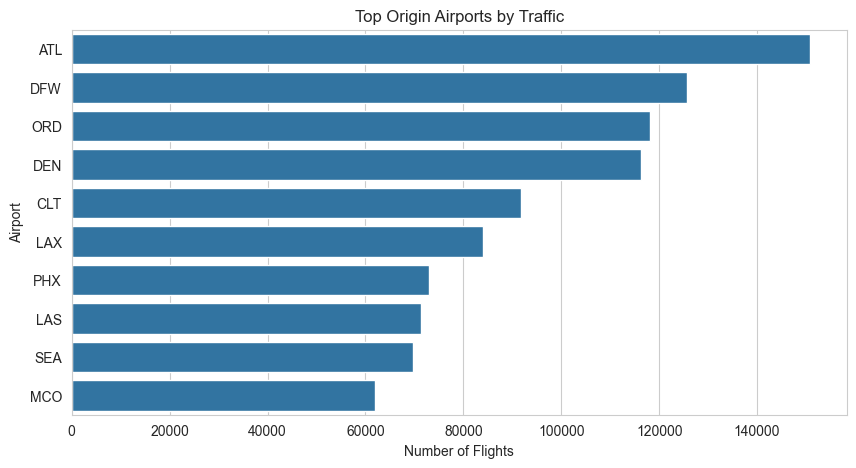

In [45]:
#PART 7: AIRPORT PERFORMANCE ANALYSIS

#Top Airports by Flight Volume
top_origins = active['ORIGIN'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_origins.values, y=top_origins.index)
plt.title("Top Origin Airports by Traffic")
plt.xlabel("Number of Flights")
plt.ylabel("Airport")
plt.show()                         #Identifies major aviation hubs.

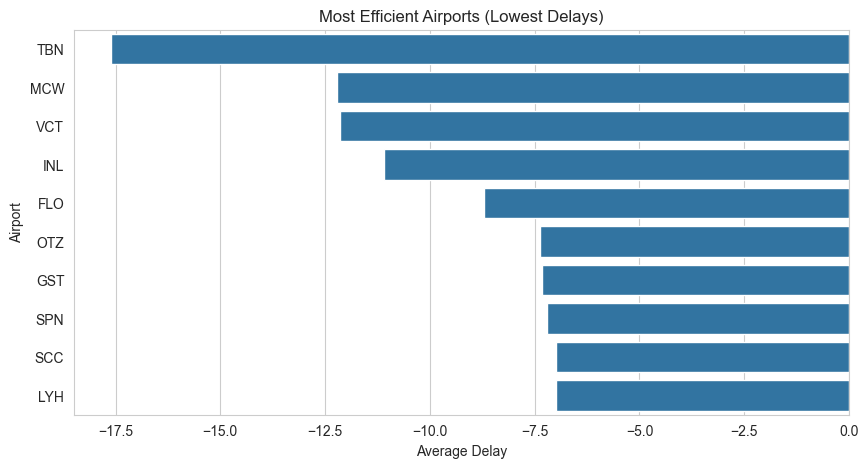

In [46]:

#Airport Delay Efficiency

airport_delay = active.groupby('ORIGIN')['ARR_DELAY'].mean().sort_values().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=airport_delay.values, y=airport_delay.index)
plt.title("Most Efficient Airports (Lowest Delays)")
plt.xlabel("Average Delay")
plt.ylabel("Airport")
plt.show()                                        #Airports with best operational efficiency.

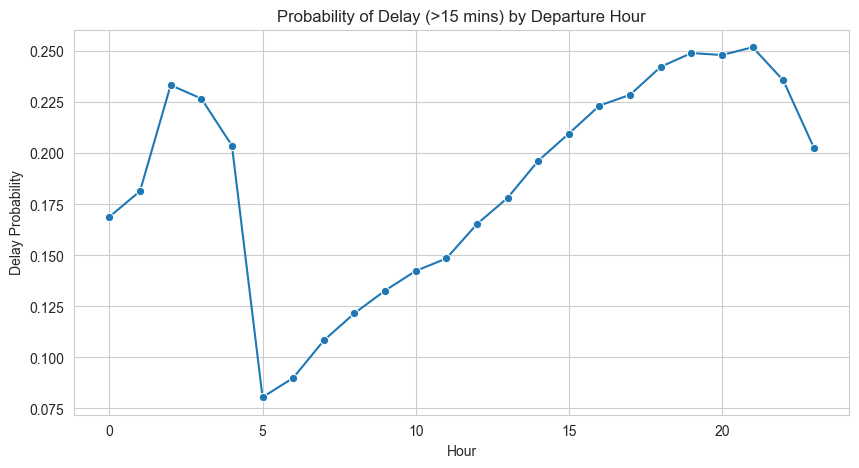

In [ ]:
#PART 8: DELAY RISK MODEL

#Delay Probability by Hour
delay_risk = active.groupby('DEP_HOUR')['ARR_DELAY'].apply(lambda x: (x > 15).mean())

plt.figure(figsize=(10,5))
sns.lineplot(x=delay_risk.index, y=delay_risk.values, marker='o')

plt.title("Probability of Delay (>15 mins) by Departure Hour")
plt.xlabel("Hour")
plt.ylabel("Delay Probability")
plt.show()                                     #Shows risk of delays at different times,Useful for scheduling optimization

In [ ]:
#PART 9: KPI DASHBOARD VIEW

total_flights = len(df)
cancel_rate = df['CANCELLED'].mean() * 100
divert_rate = df['DIVERTED'].mean() * 100
avg_delay = active['ARR_DELAY'].mean()

print("===== KPI SUMMARY =====")
print("Total Flights:", total_flights)
print("Cancellation Rate: {:.2f}%".format(cancel_rate))
print("Diversion Rate: {:.2f}%".format(divert_rate))
print("Average Arrival Delay: {:.2f} mins".format(avg_delay))   #This mimics a real business dashboard

===== KPI SUMMARY =====
Total Flights: 3000000
Cancellation Rate: 2.64%
Diversion Rate: 0.24%
Average Arrival Delay: 4.26 mins


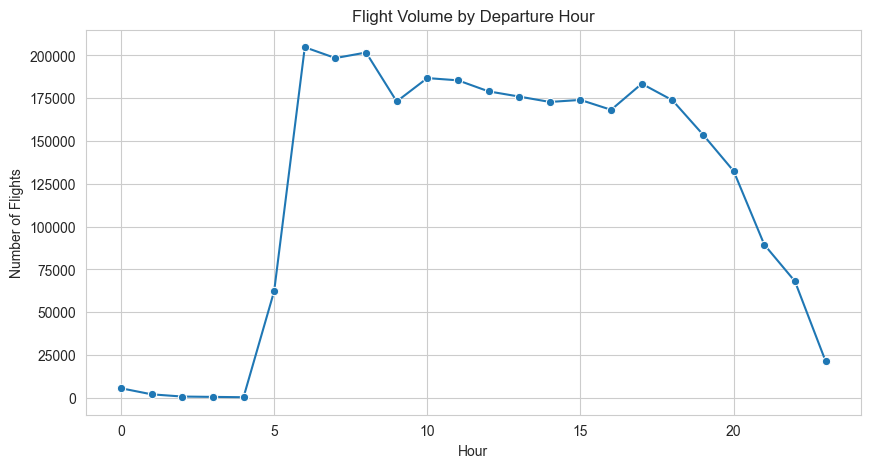

In [ ]:
#PART 10: PEAK LOAD ANALYSIS

hourly_flights = active['DEP_HOUR'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.lineplot(x=hourly_flights.index, y=hourly_flights.values, marker='o')

plt.title("Flight Volume by Departure Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Flights")
plt.show()                                          #Helps airlines manage congestion & staffing

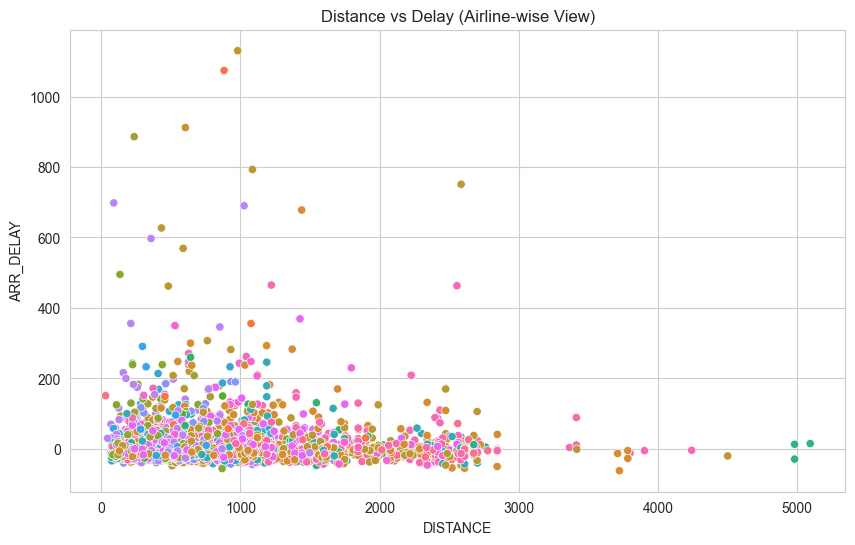

In [ ]:
#PART 11: MULTI-DIMENSION INSIGHT

#Airline vs Delay vs Distance
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=active.sample(5000),  # sample for performance
    x='DISTANCE',
    y='ARR_DELAY',
    hue='AIRLINE',
    legend=False
)

plt.title("Distance vs Delay (Airline-wise View)")
plt.show()   